### Parametric Equations of Lines and Segments

Reminder: Implicit Equations can be represented in the form of $f(x_1,x_2,...,x_n) = 0$  

We are now going to focus on how to represent equations using the paramteric form.

Reminder: 
A line  in 2D space: $ax + by + c = 0$  
A line in 3D space is reprsented using 2 equations:  
$a_1x + b_1y + c_1z + d_1 = 0$   
$a_2x + b_2y + c_2z + d_2 = 0$

This is due to the fact that a line is a 1D entity, so whatever the space may be we must reduce the degrees of freedom to 1D.

Q. Isn't there a way to represent an equation of a line for ANY dimension using JUST ONE EQUATION?

Consider a line and point $p_0$ on this line (imagine that this line is in a "normal" 2D space). 
1. We define the direction of the line using a normalized vector $\vec{v}$.
2. any point $p$ that lies on the line must satisfy the equation: $$\exist t \in \R \mid p = p_0 + t\vec{v}$$  

As such $p(t) = p_0 + t\vec{v}$ will define a line passing through $p_0$, which has the direction parallel to the $\vec{v}$. Since $\vec{v}$ is normalised then we conclude that $|t| := dist(p, p_0)$

### Exercise 
Given a point $p_0 = (1,2,3)$ and a direction vector $\vec{v} = (1,1,1)$ determine the set of points that lie on the line $p + t\vec{v}$ in which $dist(p, p_0) = √3$

### Solution

1. Check/Normalise the given vector $$|\vec{v}| = \sqrt(1^2 + 1^2 + 1^2) = \sqrt3 $$ so $$\vec{v_n} = (\frac{1}{\sqrt3}, \frac{1}{\sqrt3}, \frac{1}{\sqrt3})$$
2. Since $\vec{v_n}$ is normalised the value of $t := dist(p, p_0)$ so we need $|t| = √3$ so t = √3 or -√3.
3. For $t = √3$:  
$p_1 = (1, 2, 3) + √3·(1/√3, 1/√3, 1/√3)$  
so $p_1 = (1, 2, 3) + (1, 1, 1)$  
so $p_1 = (2, 3, 4)$  
4. For $t = -√3$:  
$p_1 = (1, 2, 3) + -√3·(1/√3, 1/√3, 1/√3)$  
so $p_1 = (1, 2, 3) -(1, 1, 1)$  
so $p_1 = (0, 1, 2)$


we see that t becomes the parameter in the equation of a line. 
$$p(t) = (1-t)p_0 + tp_1$$  
This can be expanded in $E^3$ space where $p_0 = (x_0, y_0, z_0)$ and $p_1 = (x_1, y_1, z_1)$ (not $p_0$ is our semantic starting point) we obtain: $$p(t) = (x(t), y(t), z(t)) = ((1-t)x_0 + tx_1, (1-t)y_0 + ty_1, (1-t)z_0 + tz_1)$$  
We can see that this is expandible to any dimention we just need to add additional dimensions on the parameter.

A parametric representation maps the parametric space into the geometruc space by using N coordinate functions, where N is the dimension of the geometric space G.  
The dimension of the paramtric space define the degrees of freedom of the point of the object. The geomtric spcae G is sometimes reffered as the embedding space as the object is embedded within it.

### constraining the paramter $t$
1. what would happen if $t ≥ 0$ and we have $p(t) = (1-t)p_0 + tp_0$, how does this effect the types of objects that can be defined in the geometric space.  
if $t = 0$ implies the $p(t) = p_0$  
2. What would happen if $0 ≤ t ≤ 1$ and we have $p(t) = (1-t)p_0 + tp_0$, how does this effect the types of objects that can be defined in the geometric space.  
We'll define a closed line segment between $p_0$ and $p_1$, since $t = 0$ we obtain $p(t) = p_0$ and $t= 1$ we obtain $p(t) = p_1$ and when $t= 0.5$ we obtain $p(t) = 0.5•p_0 + 0.5•p_1$

Notice that when $0 ≤ t ≤ 1$ we produce a paramteric equation which also is an $Affine\ Combination$ of points. (This is also knwon as a $convex\ combination$ since $t≥0$ and $(1-t)≥0$).  
This also happens to be the simplest $convex\ combination$. 

### Convex definition

A set S of points is convex if for every two points $p_0$, $p_1$ that are in the set, any point $p$ on the segment between them is also in the set.

#### Convex Combination of n points  

A convex combination of n points $p_1, p_2, ..., p_n$ in any dimension is expressed as:

$$p = \sum_{i=1}^{n} \alpha_i p_i$$

where:

$\alpha_i \geq 0$ for all $i$ (non-negative coefficients)
$\sum_{i=1}^{n} \alpha_i = 1$ (coefficients sum to 1)

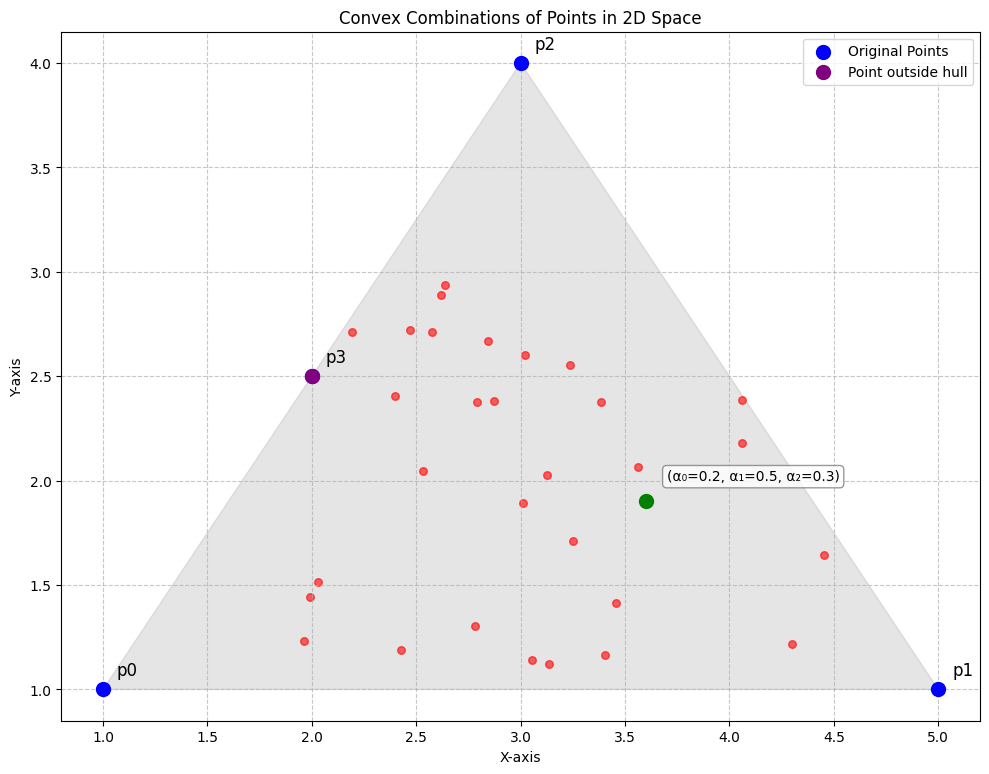

Convex Combination Formula:
p = α₀p₀ + α₁p₁ + α₂p₂
Where: α₀, α₁, α₂ ≥ 0 and α₀ + α₁ + α₂ = 1


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# Define some points in 2D
points = np.array([
    [1, 1],    # p0
    [5, 1],    # p1
    [3, 4],    # p2
    [2, 2.5],  # p3
])

# Plot the original points and their convex hull
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(points[:, 0], points[:, 1], color='blue', s=100, zorder=3, label='Original Points')

# Label the original points
for i, (x, y) in enumerate(points):
    ax.annotate(f'p{i}', (x, y), xytext=(10, 10), textcoords='offset points', fontsize=12)

# Create the convex hull (in this case, we'll use a triangle from the first 3 points for simplicity)
hull_points = points[:3]  # Using first 3 points
hull = Polygon(hull_points, alpha=0.2, color='gray')
ax.add_patch(hull)

# Generate some random convex combinations of the first 3 points
num_combinations = 30
np.random.seed(42)  # For reproducibility

# Function to generate random convex combination coefficients
def random_convex_coefficients(n):
    alphas = np.random.rand(n)
    return alphas / alphas.sum()

# Generate and plot convex combinations
for _ in range(num_combinations):
    # Generate random coefficients that sum to 1
    alphas = random_convex_coefficients(3)
    
    # Calculate the convex combination
    convex_point = np.zeros(2)
    for i in range(3):
        convex_point += alphas[i] * points[i]
    
    ax.scatter(convex_point[0], convex_point[1], color='red', alpha=0.6, s=30)

# Special convex combination demonstration
# Show a specific example with coefficients displayed
special_alphas = [0.2, 0.5, 0.3]  # These sum to 1
special_point = np.zeros(2)
for i in range(3):
    special_point += special_alphas[i] * points[i]

ax.scatter(special_point[0], special_point[1], color='green', s=100, zorder=3)
ax.annotate(f'(α₀={special_alphas[0]}, α₁={special_alphas[1]}, α₂={special_alphas[2]})', 
           (special_point[0], special_point[1]), 
           xytext=(15, 15), 
           textcoords='offset points',
           fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Demonstrate a point outside the convex hull (p3)
ax.scatter(points[3, 0], points[3, 1], color='purple', s=100, zorder=3, label='Point outside hull')

# Add labels and legend
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('Convex Combinations of Points in 2D Space')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

# Set equal aspect ratio
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Print formula for convex combinations
print("Convex Combination Formula:")
print("p = α₀p₀ + α₁p₁ + α₂p₂")
print("Where: α₀, α₁, α₂ ≥ 0 and α₀ + α₁ + α₂ = 1")